# Predicción de Ratings Altos en MovieLens 25M
## Trabajo Práctico Final - Aprendizaje de Máquina I (CEIA - FIUBA)

**Autores:** Jose Miguel Silva Pavón, Pablo Santiago Rodríguez Castro, Damian Nicolas Smilovich
**Dataset:** [MovieLens 25M](https://grouplens.org/datasets/movielens/25m/) (Harper & Konecny, 2015)  
**Fecha:** Abril 2026  

---

**Pregunta de investigación:** *¿Es posible predecir si un usuario calificará una película con 4 o más estrellas, usando features de contenido, perfil de comportamiento del usuario y señales del tag genome?*

**Clasificación binaria:** `rating >= 4.0 -> 1` (le gustó), `else -> 0`

## 1. Imports y Configuración

In [1]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import urllib.request
import zipfile
from pathlib import Path
from tqdm import tqdm
import shutil

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, brier_score_loss,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score as f1_fn, precision_score as prec_fn, recall_score as rec_fn
from sklearn.dummy import DummyClassifier
import xgboost as xgb
import optuna
import shap

from scipy.cluster.hierarchy import dendrogram, linkage

from movielens_data import MovieLensDataset, evaluate_classifier, train_test_generic, obtain_best_threshold
from auxiliary import *

# Configuración
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
optuna.logging.set_verbosity(optuna.logging.WARNING)

[12:08:55] started


## 2. Carga de Datos

In [2]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
DATA_PATH = "./data/ml-25m"
data_dir = Path(DATA_PATH)
data_dir.parent.mkdir(parents=True, exist_ok=True)

# Lo descargamos si no está en el directorio esperado
if not data_dir.exists():
    print("Descargando MovieLens 25M dataset...")

    # URL de descarga
    url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
    zip_path = "./data/ml-25m.zip"

    try:
        urllib.request.urlretrieve(url, zip_path)
        
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall("./data")
        
        # Chequeamos si es necesario reorganizar la estructura de directorios (grouplens deja los archivos en ml-25m/)
        extracted_path = Path("./data/ml-25m")
        if extracted_path.exists() and not (extracted_path / "ratings.csv").exists():
            for file in extracted_path.glob("ml-25m/*"):
                shutil.move(str(file), str(extracted_path / file.name))
        
        os.remove(zip_path)
        print(f"Dataset extraído en {DATA_PATH}")
        
    except Exception as e:
        print("Error al descargar, descargar manualmente desde: https://grouplens.org/datasets/movielens/25m/")

required_files = ["ratings.csv", "movies.csv", "genome-scores.csv", "genome-tags.csv", "links.csv", "tags.csv"]
missing_files = [f for f in required_files if not (data_dir / f).exists()]

if missing_files:
    print(f"Archivos faltantes: {missing_files}")

#obtener tamaño del directorio data
data_size = sum(f.stat().st_size for f in data_dir.glob("**/*") if f.is_file())
print(f"Tamaño del directorio de datos: {data_size / (1024 * 1024):.2f} MB")

[12:08:56] started
Tamaño del directorio de datos: 1103.09 MB
CPU times: user 1.48 ms, sys: 0 ns, total: 1.48 ms
Wall time: 1.1 ms


In [3]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
DATA_PATH = "./data/ml-25m"

# Leemos el dataset
print("[...] loading ratings.csv...")
ratings_raw = pd.read_csv(f"{DATA_PATH}/ratings.csv")
print("[...] loading movies.csv...")
movies_raw = pd.read_csv(f"{DATA_PATH}/movies.csv")
print("[...] done loading CSVs")

print(f"Ratings: {len(ratings_raw):,} filas")
print(f"Películas: {len(movies_raw):,} filas")

[12:08:56] started
[...] loading ratings.csv...
[...] loading movies.csv...
[...] done loading CSVs
Ratings: 25,000,095 filas
Películas: 62,423 filas


In [4]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
ratings_raw.head()

[12:09:04] started


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [5]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
ratings_raw.info()

[12:09:04] started
<class 'pandas.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB


In [6]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
movies_raw.head()

[12:09:04] started


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 3. Análisis Exploratorio de Datos (EDA)
Para el EDA usamos el 5% del dataset (aprox 1.25M de filas).

In [7]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
ratings_eda = ratings_raw.sample(frac=0.05, random_state=42).copy()
print(f'ratings_eda: {len(ratings_eda):,} filas ({len(ratings_eda)/len(ratings_raw)*100:.1f}% del total)')

[12:09:04] started
ratings_eda: 1,250,005 filas (5.0% del total)


[12:09:05] started


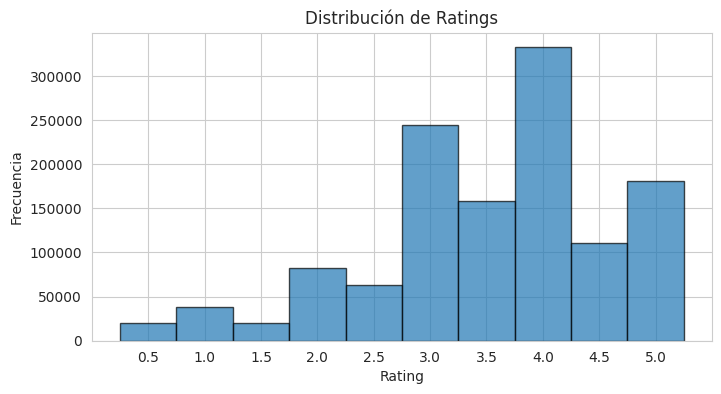

In [8]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
fig, ax = plt.subplots(figsize=(8, 4))
plot_rating_distribution(ratings_eda, ax=ax)
plt.show()

Vemos que la distribución tiene cola hacia ratings más altos.

[12:09:05] started


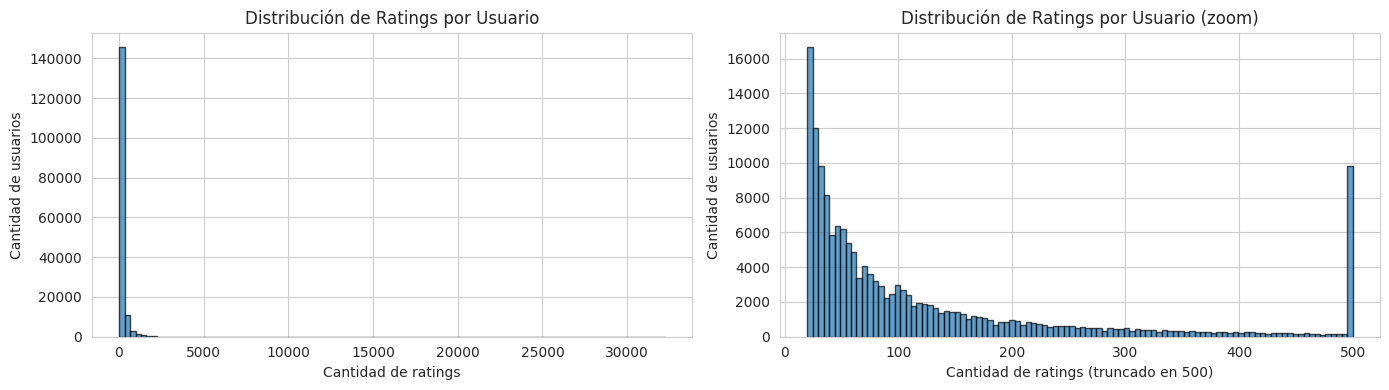

Usuarios únicos: 162,541
Mediana de ratings por usuario: 71
Media de ratings por usuario: 153.8
Usuarios con >= 50 ratings:102,492


In [9]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Ratings por usuario
ratings_per_user = ratings_raw.groupby("userId").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(ratings_per_user, bins=100, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Cantidad de ratings")
axes[0].set_ylabel("Cantidad de usuarios")
axes[0].set_title("Distribución de Ratings por Usuario")

axes[1].hist(ratings_per_user.clip(upper=500), bins=100, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Cantidad de ratings (truncado en 500)")
axes[1].set_ylabel("Cantidad de usuarios")
axes[1].set_title("Distribución de Ratings por Usuario (zoom)")

plt.tight_layout()
plt.show()

print(f"Usuarios únicos: {ratings_per_user.count():,}")
print(f"Mediana de ratings por usuario: {ratings_per_user.median():.0f}")
print(f"Media de ratings por usuario: {ratings_per_user.mean():.1f}")
print(f"Usuarios con >= 50 ratings:{(ratings_per_user >= 50).sum():,}")

Vemos claros outliers, capeamos en 500.

[12:09:06] started


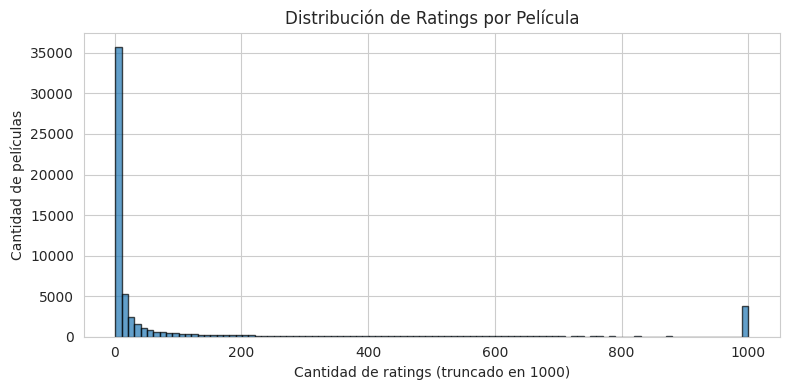

Mediana de ratings por película: 6
Películas con >= 100 ratings: 10,326


In [10]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Ratings por película
ratings_per_movie = ratings_raw.groupby("movieId").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratings_per_movie.clip(upper=1000), bins=100, edgecolor="black", alpha=0.7)
ax.set_xlabel("Cantidad de ratings (truncado en 1000)")
ax.set_ylabel("Cantidad de películas")
ax.set_title("Distribución de Ratings por Película")
plt.tight_layout()
plt.show()

print(f"Mediana de ratings por película: {ratings_per_movie.median():.0f}")
print(f"Películas con >= 100 ratings: {(ratings_per_movie >= 100).sum():,}")

[12:09:06] started


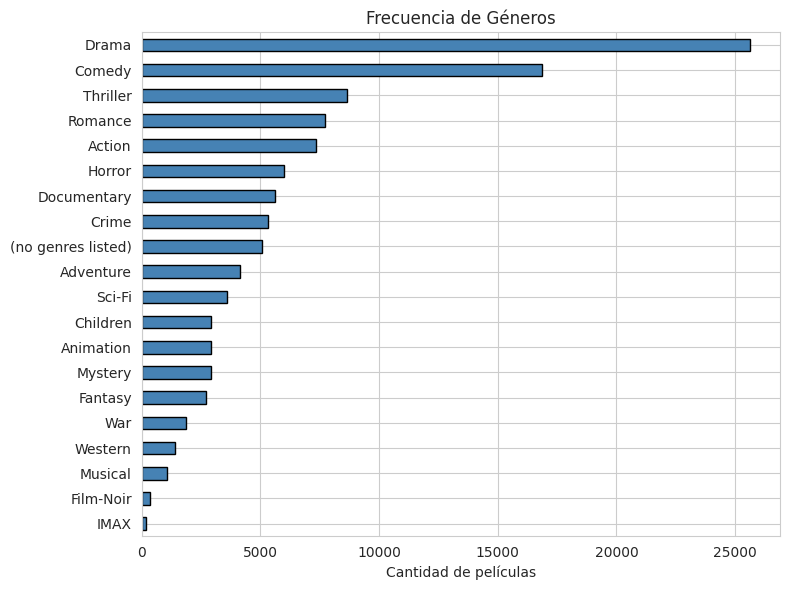

In [11]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Frecuencia de géneros
GENRES = MovieLensDataset.GENRES

fig, ax = plt.subplots(figsize=(8, 6))
plot_genre_frequency(movies_raw, GENRES, ax=ax)
plt.tight_layout()
plt.show()

[12:09:07] started


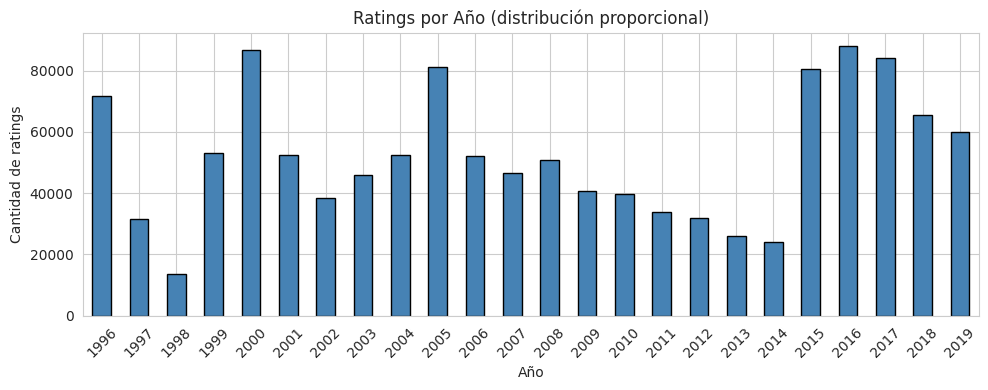

In [12]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Ratings por año
ratings_eda["datetime"] = pd.to_datetime(ratings_eda["timestamp"], unit="s")
ratings_eda["year_rated"] = ratings_eda["datetime"].dt.year

ratings_by_year = ratings_eda.groupby("year_rated").size()

fig, ax = plt.subplots(figsize=(10, 4))
ratings_by_year.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de ratings")
ax.set_title("Ratings por Año (distribución proporcional)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

[12:09:07] started


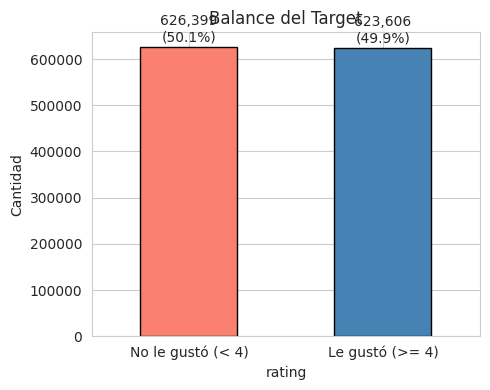

In [13]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Balanceo del target
target = (ratings_eda["rating"] >= 4.0).astype(int)
target_counts = target.value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", ax=ax, color=["salmon", "steelblue"], edgecolor="black")
ax.set_xticklabels(["No le gustó (< 4)", "Le gustó (>= 4)"], rotation=0)
ax.set_ylabel("Cantidad")
ax.set_title("Balance del Target")
for i, v in enumerate(target_counts):
    ax.text(i, v + len(ratings_eda) * 0.01, f"{v:,}\n({v/len(ratings_eda)*100:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

Dado que entrenaremos un modelo de clasificación binaria, balanceamos las muestras aprox. 50-50 para darle igual peso a ambos casos.

## 4. Pregunta de Investigación e Hipótesis

### Pregunta
**¿Podemos predecir si un usuario calificará una película con 4 estrellas o más usando features como género, año, popularidad, perfil de comportamiento del usuario (ej. promedios, dispersión, preferencias) y señales del tag genome (dataset de "tags" conceptuales)?**

### Hipótesis
- **1:** Los modelos de ensamble (Random Forest, Gradient Boosting, XGBoost) superarán a los modelos individuales (KNN, SVM, Árboles) en F1-score, dado que el dataset combina features muy diversas y heterogéneas.
- **2:** Las features de perfil de usuario (sobre todo `user_avg_rating` y `user_deviation_from_movie_avg`) serán las más predictivas, ya que capturan la tendencia personal del usuario a calificar como alto o bajo.
- **3:** Los componentes PCA del tag genome aportarán información complementaria al género one-hot, mejorando la capacidad discriminativa.

### Justificación del enfoque
La formulación como clasificación binaria permite aplicar los algoritmos relevantes para este problema vistos en la materia (KNN, SVM, Árboles, Ensambles, Calibración) y puede ser insumo para experimentos posteriores más complejos asociados con sistemas de recomendación: predecir si a un usuario le gustará una película es equivalente a decidir si recomendarla.

## 5. Muestreo y Feature Engineering

Estrategia de muestreo:
1. Filtrar usuarios con >= 50 ratings (usuarios activos)
2. Muestrear 5k usuarios (`random_state=42`)
3. Tomar 200k ratings (estratificado por target)
4. SVM y KNN usarán un subconjunto de 50K (por costo computacional)

In [14]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
dataset = MovieLensDataset(data_path=DATA_PATH, n_users=20000, n_ratings=1000000,)

[12:09:07] started
Cargando ratings.csv ...
25,000,095 ratings cargados
Cargando movies.csv ...
62,423 películas cargadas
Cargando genome-scores.csv ...
15,584,448 registros de genome cargados
Usuarios totales: userId
1          70
2         184
3         656
4         242
5         101
         ... 
162537    101
162538    154
162539     47
162540     88
162541    182
Length: 162541, dtype: int64
Se mantienen usuarios con >= 50 ratings: 102,492
Se samplean 20000 usuarios y se filtran sus ratings.
REVISAR SI EL TAMAÑO DEL SAMPLE ES SUFICIENTE respecto del total de userId
1          70
2         184
3         656
4         242
5         101
         ... 
162537    101
162538    154
162539     47
162540     88
162541    182
Length: 162541, dtype: int64
Ratings de 20,000 usuarios: 4,542,093
Se muestrean 1000000 ratings estratificados por target, manteniendo la proporción original del dataset filtrado.
Se ajusta el muestreo para alcanzar exactamente 1000000 ratings.
Se agregan 1 ratings ad

In [15]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# verificar dimensiones
X_train, X_test, y_train, y_test = dataset.data_tuple
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Balance train - clase 1: {y_train.mean():.3f}")
print(f"Balance test  - clase 1: {y_test.mean():.3f}")
print(f"\nFeatures ({len(dataset.feature_names)}):")
for i, f in enumerate(dataset.feature_names):
    print(f"  {i+1:2d}. {f}")

[12:09:33] started
X_train: (700000, 71)
X_test:  (300000, 71)
Balance train - clase 1: 0.486
Balance test  - clase 1: 0.486

Features (71):
   1. genre_Action
   2. genre_Adventure
   3. genre_Animation
   4. genre_Children
   5. genre_Comedy
   6. genre_Crime
   7. genre_Documentary
   8. genre_Drama
   9. genre_Fantasy
  10. genre_Film-Noir
  11. genre_Horror
  12. genre_IMAX
  13. genre_Musical
  14. genre_Mystery
  15. genre_Romance
  16. genre_Sci-Fi
  17. genre_Thriller
  18. genre_War
  19. genre_Western
  20. genre_(no genres listed)
  21. movie_avg_rating
  22. movie_rating_count_log
  23. movie_rating_std
  24. year
  25. genome_pca_0
  26. genome_pca_1
  27. genome_pca_2
  28. genome_pca_3
  29. genome_pca_4
  30. genome_pca_5
  31. genome_pca_6
  32. genome_pca_7
  33. genome_pca_8
  34. genome_pca_9
  35. genome_pca_10
  36. genome_pca_11
  37. genome_pca_12
  38. genome_pca_13
  39. genome_pca_14
  40. genome_pca_15
  41. genome_pca_16
  42. genome_pca_17
  43. genome_pc

[12:09:34] started


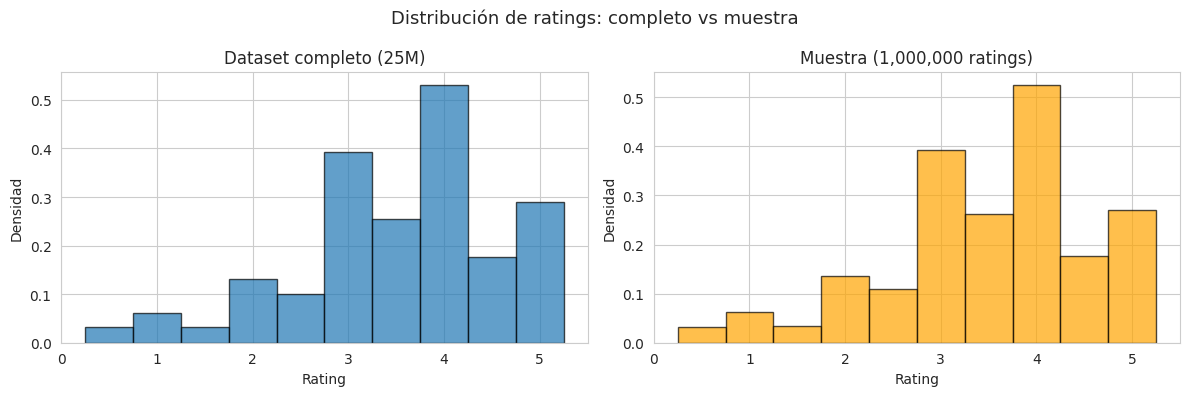

In [16]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Comparación de distribución antes/después del muestreo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ratings_raw["rating"], bins=np.arange(0.25, 5.75, 0.5), edgecolor="black", alpha=0.7, density=True)
axes[0].set_title("Dataset completo (25M)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Densidad")

axes[1].hist(dataset.df_features["rating"], bins=np.arange(0.25, 5.75, 0.5), edgecolor="black", alpha=0.7, density=True, color="orange")
axes[1].set_title(f"Muestra ({len(dataset.df_features):,} ratings)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Densidad")

plt.suptitle("Distribución de ratings: completo vs muestra", fontsize=13)
plt.tight_layout()
plt.show()

[12:09:34] started


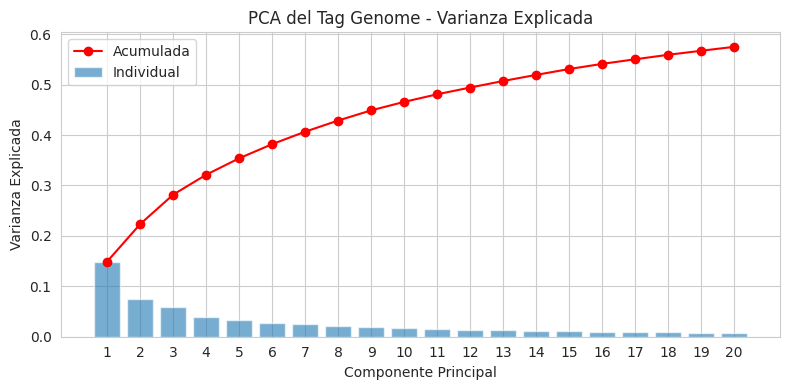

Varianza total explicada con 20 componentes: 0.575


In [17]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Scree plot del PCA del tag genome
fig, ax = plt.subplots(figsize=(8, 4))
explained = dataset.genome_explained_variance
cumulative = np.cumsum(explained)

ax.bar(range(1, len(explained) + 1), explained, alpha=0.6, label="Individual")
ax.plot(range(1, len(explained) + 1), cumulative, "ro-", label="Acumulada")
ax.set_xlabel("Componente Principal")
ax.set_ylabel("Varianza Explicada")
ax.set_title("PCA del Tag Genome - Varianza Explicada")
ax.legend()
ax.set_xticks(range(1, len(explained) + 1))
plt.tight_layout()
plt.show()

print(f"Varianza total explicada con {len(explained)} componentes: {cumulative[-1]:.3f}")

#### Interpretación de genome_pca_0

`genome_pca_0` interpretamos que este componente representa la calidad artistica, parece separar peliculas de culto de las pochocleras.

- **Valores altos** -> películas con tags como *social commentary*, *criterion*, *golden palm* (Cannes),
  *oscar (best directing)*, *cinematography*, *enigmatic*, *bleak*. Ejemplos: *Parasite*, *2001: A Space Odyssey*.
- **Valores bajos** -> películas con tags como *predictable*, *franchise*, *teen movie*, *silly*, *lame*.
  Ejemplos: *Transformers*, *Scary Movie 4*.

Que este componente aparezca alto en feature importance de XGBoost tiene sentido, los usuarios activos de MovieLens tienden a ser gente de tendencia cinéfila que valoran más el cine de calidad.

[12:09:34] started


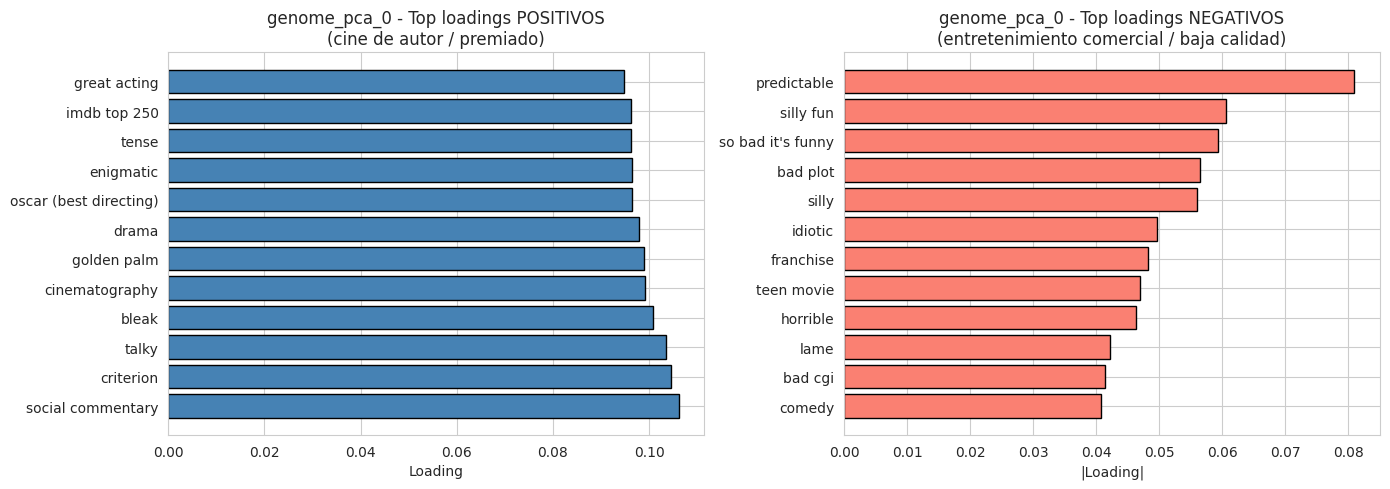

In [18]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# identificar los tags con mayor peso positivo y negativo en genome_pca_0
genome_tags = pd.read_csv(f"{DATA_PATH}/genome-tags.csv")
pca_loadings = dataset.genome_pca.components_[0]

top_n = 12
pos_idx = pca_loadings.argsort()[-top_n:][::-1]
neg_idx = pca_loadings.argsort()[:top_n]

pos_tags = genome_tags.iloc[pos_idx][['tagId', 'tag']].copy()
pos_tags['loading'] = pca_loadings[pos_idx]
neg_tags = genome_tags.iloc[neg_idx][['tagId', 'tag']].copy()
neg_tags['loading'] = pca_loadings[neg_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(pos_tags['tag'], pos_tags['loading'], color='steelblue', edgecolor='black')
axes[0].set_title('genome_pca_0 - Top loadings POSITIVOS\n(cine de autor / premiado)')
axes[0].set_xlabel('Loading')

axes[1].barh(neg_tags['tag'][::-1], np.abs(neg_tags['loading'][::-1]), color='salmon', edgecolor='black')
axes[1].set_title('genome_pca_0 - Top loadings NEGATIVOS\n(entretenimiento comercial / baja calidad)')
axes[1].set_xlabel('|Loading|')

plt.tight_layout()
plt.show()

#### Vemos las correlaciones entre las principales features del dataset.

[12:09:34] started


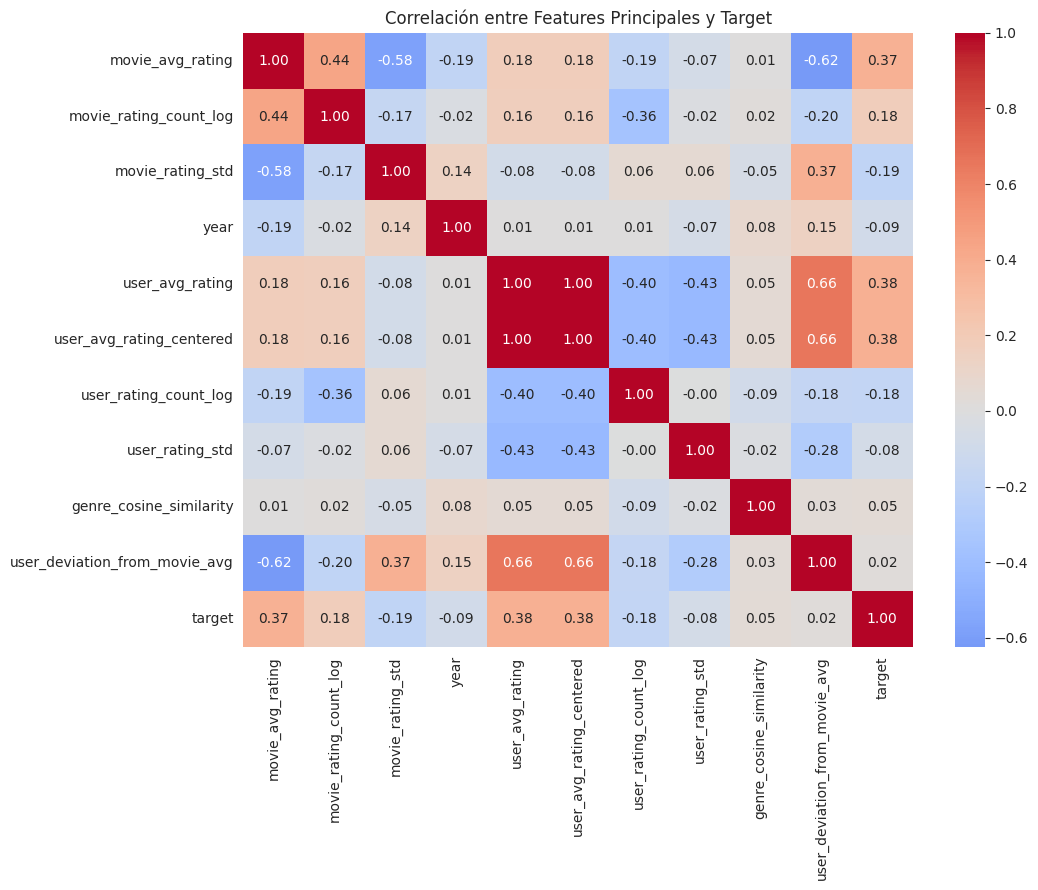

In [19]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# heatmap de correlación
corr_cols = [
    "movie_avg_rating", "movie_rating_count_log", "movie_rating_std", "year",
    "user_avg_rating", "user_avg_rating_centered", "user_rating_count_log", "user_rating_std",
    "genre_cosine_similarity", "user_deviation_from_movie_avg", "target",
]

fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = dataset.df_features[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre Features Principales y Target")
plt.tight_layout()
plt.show()

#### Vemos que la calificación promedio del usuario y su desviación respecto de las calificaciones medias de los usuarios por película, estan positivamente correlacionadas, lo cual, tiene sentido y además son las que mejor correlacionan con el target de entrenamiento.

## 6. Modelado

Almacenaremos los resultados de cada modelo en una lista para comparación final.

In [20]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Lista para acumular métricas de todos los modelos
all_metrics = []
trained_models = {}

# Núcleos disponibles (reservamos 1 para el SO)
n_cores = os.cpu_count() - 1

# Subconjunto para modelos costosos
data_subset = dataset.get_subset(n=30_000)


[12:09:35] started


## 6. Baseline

Antes de entrenar cualquier modelo de ML, establecemos un piso de referencia
mediante reglas heurísticas simples, sin aprendizaje. Esto nos permite evaluar
si los modelos posteriores aportan valor real.

- **Item Mean**: predice 1 si la película tiene una media de ratings por encima de la media global.
- **User Mean**: predice 1 si el usuario tiende a dar ratings por encima de la media global.

> Las features están escaladas (StandardScaler), por lo que el umbral de
> decisión es 0 en lugar de 4.0.

In [21]:
print(f"movie_avg_rating min/max: {X_train[:, 20].min():.3f} / {X_train[:, 20].max():.3f}")
print(f"user_avg_rating  min/max: {X_train[:, 44].min():.3f} / {X_train[:, 44].max():.3f}")

movie_avg_rating min/max: -6.595 / 3.215
user_avg_rating  min/max: -5.183 / 3.131


In [22]:
# Item Mean Baseline (movie_avg_rating > 4.0)
y_pred_item = (X_test[:, 20] > 0).astype(int)
y_pred_proba_item = y_pred_item.astype(float)
item_metrics = evaluate_classifier("Item Mean Baseline", y_test, y_pred_item, y_pred_proba_item)
all_metrics.append(item_metrics)

In [23]:
# User Mean Baseline
y_pred_user = (X_test[:, 44] > 0).astype(int)
y_pred_proba_user = y_pred_user.astype(float)
user_metrics = evaluate_classifier("User Mean Baseline", y_test, y_pred_user, y_pred_proba_user)
all_metrics.append(user_metrics)

[12:09:36] started


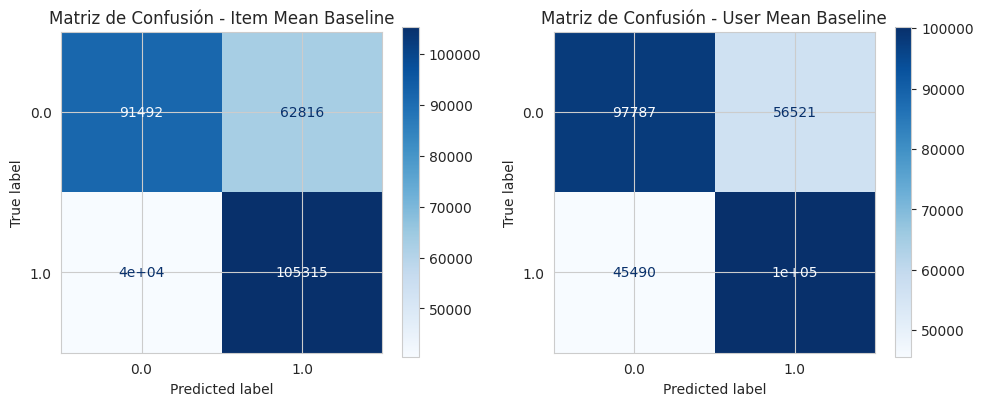

In [24]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_item, ax=axes[0], cmap="Blues")
axes[0].set_title("Matriz de Confusión - Item Mean Baseline")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_user, ax=axes[1], cmap="Blues")
axes[1].set_title("Matriz de Confusión - User Mean Baseline")

plt.tight_layout()
plt.show()

### 6.1 K-Nearest Neighbors (KNN)

**¿Por qué KNN?**Es un algoritmo basado en distancia que no hace suposiciones sobre la distribución de los datos. Es un buen baseline y nos permite evaluar si la estructura del espacio de features es informativa. Usamos el subconjunto de 30K por un tema de costo computacional.

- **Majority class**: predice siempre la clase mayoritaria (0). Establece el
  piso de accuracy e ilustra el desbalance de clases del dataset.

In [25]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
dummy_majority = DummyClassifier(strategy="most_frequent")
_, baseline_majority_metrics = train_test_generic("Majority Class Baseline", dummy_majority, dataset.data_tuple)
all_metrics.append(baseline_majority_metrics)

[12:09:36] started
CPU times: user 109 ms, sys: 951 μs, total: 110 ms
Wall time: 109 ms


[12:09:36] started


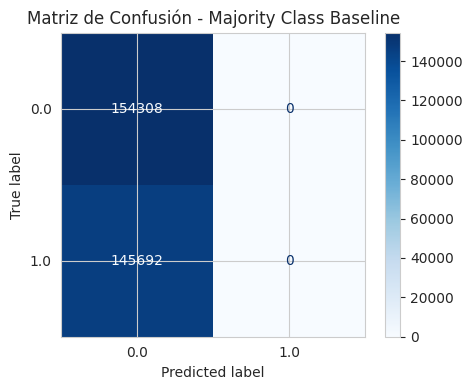

CPU times: user 182 ms, sys: 5.94 ms, total: 188 ms
Wall time: 188 ms


In [26]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Matriz de confusión Baseline
fig, ax = plt.subplots(figsize=(5, 4))
y_pred_baseline = dummy_majority.predict(dataset.data_tuple[1])
ConfusionMatrixDisplay.from_predictions(dataset.data_tuple[3], y_pred_baseline, ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusión - Majority Class Baseline")
plt.tight_layout()
plt.show()

- **Stratified**: predice aleatoriamente respetando la proporción de clases del
  training set — si el 49% del train es clase 1, predice 1 con probabilidad 0.49
  para cada ejemplo.
  En nuestro caso, dado que balanceamos el dataset 50/50, este baseline es

In [27]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
dummy_stratified = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
_, baseline_stratified_metrics = train_test_generic("Stratified Baseline", dummy_stratified, dataset.data_tuple)
all_metrics.append(baseline_stratified_metrics)

[12:09:37] started
CPU times: user 136 ms, sys: 4.01 ms, total: 140 ms
Wall time: 139 ms


[12:09:37] started


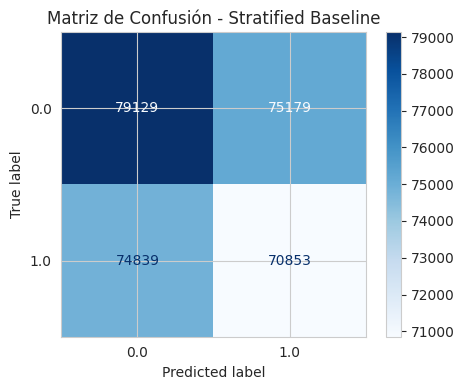

CPU times: user 207 ms, sys: 6.17 ms, total: 214 ms
Wall time: 212 ms


In [28]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Matriz de confusión Baseline
fig, ax = plt.subplots(figsize=(5, 4))
y_pred_baseline = dummy_stratified.predict(dataset.data_tuple[1])
ConfusionMatrixDisplay.from_predictions(dataset.data_tuple[3], y_pred_baseline, ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusión - Stratified Baseline")
plt.tight_layout()
plt.show()

### 6.1 K-Nearest Neighbors (KNN)

**¿Por qué KNN?** Es un algoritmo basado en distancia que no hace suposiciones sobre la distribución de los datos. Es un buen baseline y permite evaluar si la estructura local del espacio de features es informativa. Usamos el subconjunto de 30K por costo computacional.

In [29]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# GridSearchCV para KNN
knn_param_grid = {
    "n_neighbors": [5, 15, 25, 35, 50],
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=n_cores,
    verbose=0,
)
knn_grid.fit(data_subset[0], data_subset[2])

print(f"Mejores hiperparámetros: {knn_grid.best_params_}")
print(f"Mejor F1 (CV): {knn_grid.best_score_:.4f}")

[12:09:37] started
Mejores hiperparámetros: {'n_neighbors': 50, 'p': 1, 'weights': 'distance'}
Mejor F1 (CV): 0.6572
CPU times: user 91.8 ms, sys: 33.5 ms, total: 125 ms
Wall time: 38.8 s


In [30]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Evaluar mejor KNN en test del subconjunto
knn_best = knn_grid.best_estimator_
print("[...] evaluating KNN on test subset...")
knn_model, knn_metrics = train_test_generic("KNN", knn_best, data_subset)
print("[...] KNN done")
all_metrics.append(knn_metrics)
trained_models["KNN"] = knn_best

print(pd.DataFrame([knn_metrics]).to_string(index=False))

[12:10:16] started
[...] evaluating KNN on test subset...
[...] KNN done
modelo  accuracy  auc_score  precision   recall       f1  train_time_s
   KNN  0.678556   0.748549   0.681726 0.623356 0.651236       0.00176
CPU times: user 20.9 s, sys: 63.9 ms, total: 21 s
Wall time: 3.98 s


### Para un primer modelo, un f1 score de 0.65 es competitivo.

[12:10:20] started


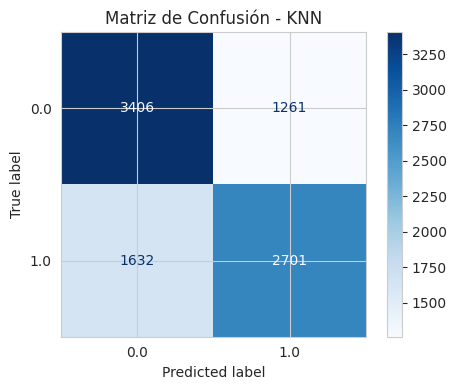

In [31]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Matriz de confusión KNN
fig, ax = plt.subplots(figsize=(5, 4))
y_pred_knn = knn_best.predict(data_subset[1])
ConfusionMatrixDisplay.from_predictions(data_subset[3], y_pred_knn, ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusión - KNN")
plt.tight_layout()
plt.show()

### 6.2 Support Vector Machine (SVM)

**¿Por qué SVM?** Busca el hiperplano de máximo margen. Para clasificacion binaria, debería ser un salto con respecto a un KNN. Evaluamos kernels lineal, polinomial y RBF para encontrar la mejor frontera de decisión. Usamos el subconjunto de 50K por el alto costo computacional.

In [32]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
data_subset[0].shape

[12:10:22] started


(21000, 71)

In [33]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
svm_results = []
for kernel in tqdm(["linear", "poly", "rbf"], desc="Entrenando SVM"):
    svc = SVC(kernel=kernel, probability=True, random_state=RANDOM_STATE, C=1.0)
    svc.fit(data_subset[0], data_subset[2])
    y_pred = svc.predict(data_subset[1])
    y_proba = svc.predict_proba(data_subset[1])[:, 1]
    metrics = evaluate_classifier(f"SVM ({kernel})", data_subset[3], y_pred, y_proba)
    svm_results.append(metrics)
    print(f"Kernel {kernel:7s} -> F1: {metrics['f1']:.4f}  AUC: {metrics['auc_score']:.4f}")

svm_df = pd.DataFrame(svm_results)
print(f"\nMejor kernel: {svm_df.loc[svm_df['f1'].idxmax(), 'modelo']}")

[12:10:22] started


Entrenando SVM:  33%|█████████████                          | 1/3 [09:23<18:47, 563.66s/it]

Kernel linear  -> F1: 0.7117  AUC: 0.7974


Entrenando SVM:  67%|██████████████████████████             | 2/3 [12:15<05:33, 333.24s/it]

Kernel poly    -> F1: 0.6800  AUC: 0.7736


Entrenando SVM: 100%|███████████████████████████████████████| 3/3 [14:59<00:00, 299.80s/it]

Kernel rbf     -> F1: 0.7125  AUC: 0.7961

Mejor kernel: SVM (rbf)
CPU times: user 14min 52s, sys: 6.56 s, total: 14min 58s
Wall time: 14min 59s


In [34]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Entrenar SVM con mejor kernel y evaluar
best_kernel = svm_df.loc[svm_df["f1"].idxmax(), "modelo"].split("(")[1].rstrip(")")
svm_best = SVC(kernel=best_kernel, probability=True, random_state=RANDOM_STATE, C=1.0)
print("[...] training & evaluating SVM...")
svm_model, svm_metrics = train_test_generic("SVM", svm_best, data_subset)
print("[...] SVM done")
all_metrics.append(svm_metrics)
trained_models["SVM"] = svm_best

print(pd.DataFrame([svm_metrics]).to_string(index=False))

[12:25:21] started
[...] training & evaluating SVM...
[...] SVM done
modelo  accuracy  auc_score  precision  recall       f1  train_time_s
   SVM     0.722   0.796107   0.709449 0.71567 0.712546    152.241808
CPU times: user 2min 47s, sys: 1.2 ms, total: 2min 47s
Wall time: 2min 47s


#### Efectivamente SVM obtuvo mejores metricas con respecto a KNN y Baseline. 

[12:28:09] started


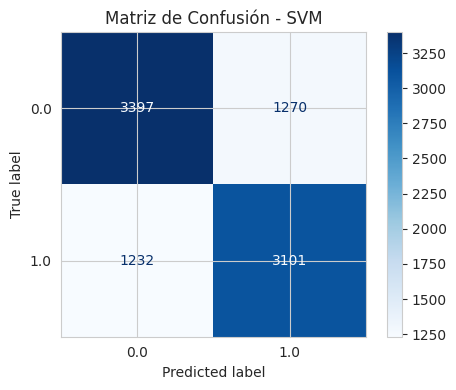

CPU times: user 8.59 s, sys: 3.98 ms, total: 8.59 s
Wall time: 8.59 s


In [35]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
fig, ax = plt.subplots(figsize=(5, 4))
y_pred_svm = svm_best.predict(data_subset[1])
ConfusionMatrixDisplay.from_predictions(data_subset[3], y_pred_svm, ax=ax, cmap="Blues")
ax.set_title("Matriz de Confusión - SVM")
plt.tight_layout()
plt.show()

### 6.3 Árboles de Decisión

**¿Por qué Árboles?** Resultan más interpretables visualmente y manejan bien las relaciones no lineales. Evaluamos poda por costo-complejidad (`ccp_alpha`) para evitar overfitting. Usamos el dataset completo (200K).

- Alpha es un parámetro que controla la complejidad del árbol: a mayor alpha, más agresiva es la poda (menos nodos).
- El cost-complexity pruning path nos da los alphas que corresponden a cada posible poda del árbol completo, lo que nos permite evaluar un rango de alphas sin tener que entrenar árboles completos para cada uno.

[12:28:18] started
Obteniendo ruta de poda (cost-complexity pruning path)...


Evaluando ccp_alpha: 100%|██████████████████████████████| 31/31 [18:25<00:00, 35.66s/alpha]


Mejor ccp_alpha: 0.001358
Mejor F1 (CV): 0.6954


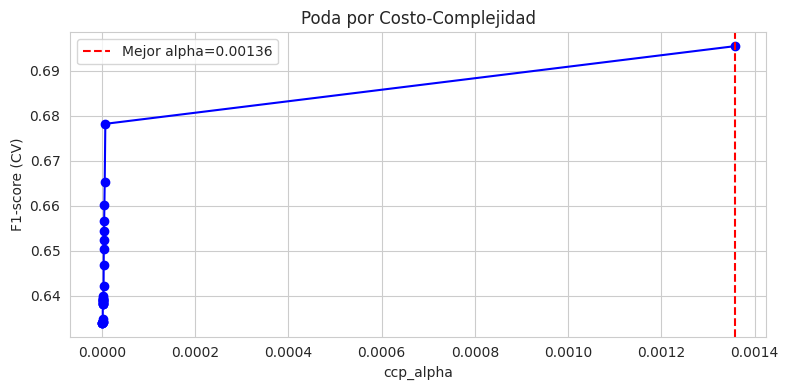

CPU times: user 2min 2s, sys: 3.42 s, total: 2min 5s
Wall time: 20min 23s


In [36]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Buscar ccp_alpha óptimo
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

print("Obteniendo ruta de poda (cost-complexity pruning path)...")
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Evaluar un rango reducido de alphas
alpha_candidates = ccp_alphas[::max(1, len(ccp_alphas) // 30)]  # ~30 valores
tree_scores = []
for alpha in tqdm(alpha_candidates, desc="Evaluando ccp_alpha", unit="alpha"):
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=RANDOM_STATE)
    scores = cross_val_score(tree, X_train, y_train, cv=3, scoring="f1", n_jobs=n_cores)
    tree_scores.append(scores.mean())

best_alpha = alpha_candidates[np.argmax(tree_scores)]
print(f"\nMejor ccp_alpha: {best_alpha:.6f}")
print(f"Mejor F1 (CV): {max(tree_scores):.4f}")

# Gráfico de poda
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alpha_candidates, tree_scores, "bo-")
ax.axvline(best_alpha, color="red", linestyle="--", label=f"Mejor alpha={best_alpha:.5f}")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("F1-score (CV)")
ax.set_title("Poda por Costo-Complejidad")
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Entrenar árbol podado y evaluar
tree_best = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=RANDOM_STATE)
print("[...] training & evaluating Decision Tree...")
tree_model, tree_metrics = train_test_generic("Árbol de Decisión", tree_best, dataset.data_tuple)
print("[...] Decision Tree done")
all_metrics.append(tree_metrics)
trained_models["Árbol de Decisión"] = tree_best

print(pd.DataFrame([tree_metrics]).to_string(index=False))
print(f"\nProfundidad del árbol: {tree_best.tree_.max_depth}")
print(f"Cantidad de hojas: {tree_best.tree_.n_leaves}")

[12:48:41] started
[...] training & evaluating Decision Tree...
[...] Decision Tree done
           modelo  accuracy  auc_score  precision   recall       f1  train_time_s
Árbol de Decisión   0.70423    0.77069    0.68637 0.719937 0.702753     74.451346

Profundidad del árbol: 4
Cantidad de hojas: 11
CPU times: user 1min 14s, sys: 2.76 ms, total: 1min 14s
Wall time: 1min 14s


#### Para nuestra sorpresa, un arbol de decisión por si solo, aun con todo el dataset, no le ganó al SVM con un dataset reducido. Veremos como le va en el contexto de un ensamble.

[12:49:55] started


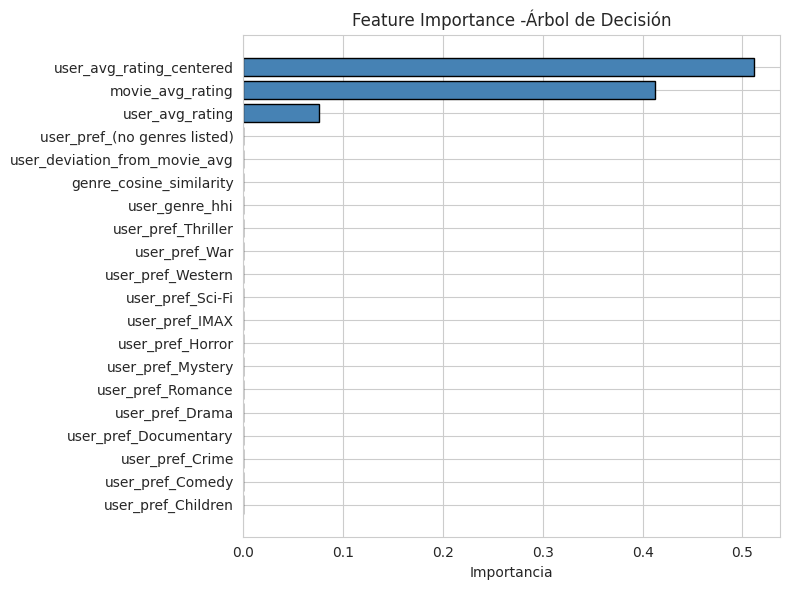

CPU times: user 169 ms, sys: 6.03 ms, total: 175 ms
Wall time: 175 ms


In [38]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Feature importance del árbol
fig, ax = plt.subplots(figsize=(8, 6))
plot_feature_importance(dataset.feature_names, tree_best.feature_importances_, top_n=20, ax=ax)
ax.set_title("Feature Importance -Árbol de Decisión")
plt.tight_layout()
plt.show()

#### El arbol le dió una importancia despreciable a todas las features por debajo del top-3.

### Lo visualizamos:

[12:49:56] started


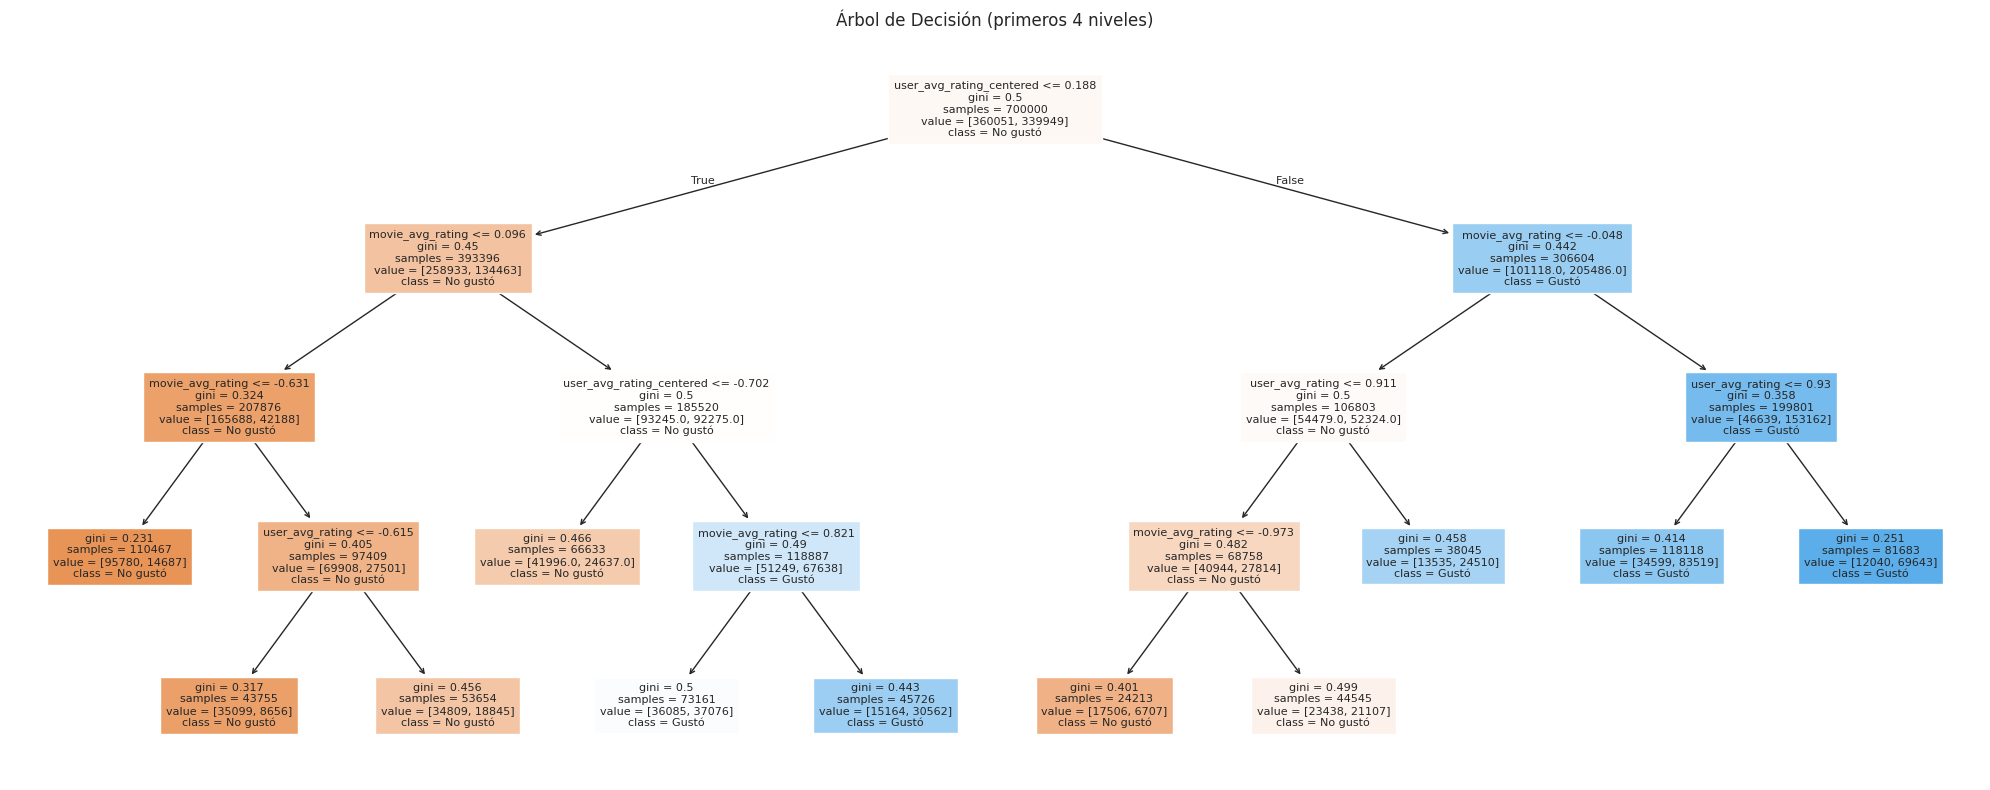

In [39]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Visualización parcial del árbol (primeros 4 niveles)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    tree_best,
    feature_names=dataset.feature_names,
    class_names=["No gustó", "Gustó"],
    filled=True,
    max_depth=4,
    ax=ax,
    fontsize=8,
)
ax.set_title("Árbol de Decisión (primeros 4 niveles)")
plt.tight_layout()
plt.show()

#### Como podemos ver, el arbol se centró en 3 features discretizadas de alto poder predictivo, pero no parece un modelo que explote la información de manera apropiada. 

### 6.4 Ensambles

**¿Por qué Ensambles?** Combinan múltiples modelos débiles para reducir varianza (bagging) o sesgo (boosting). Son generalmente los modelos más competitivos en datos tabulares. Evaluamos Random Forest, AdaBoost, Gradient Boosting, XGBoost, Voting,y Stacking.

In [40]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5,
                            random_state=RANDOM_STATE, n_jobs=n_cores)
rf_model, rf_metrics = train_test_generic("Random Forest", rf, dataset.data_tuple)
all_metrics.append(rf_metrics)
trained_models["Random Forest"] = rf

print("Random Forest:")
print(pd.DataFrame([rf_metrics]).to_string(index=False))

[12:49:56] started
Random Forest:
       modelo  accuracy  auc_score  precision   recall       f1  train_time_s
Random Forest  0.733067   0.813279   0.720497 0.735778 0.728057    142.822603
CPU times: user 12min 20s, sys: 1.31 s, total: 12min 22s
Wall time: 2min 30s


In [41]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE)
ada_model, ada_metrics = train_test_generic("AdaBoost", ada, dataset.data_tuple)
all_metrics.append(ada_metrics)
trained_models["AdaBoost"] = ada

print("AdaBoost:")
print(pd.DataFrame([ada_metrics]).to_string(index=False))

[12:52:27] started
AdaBoost:
  modelo  accuracy  auc_score  precision   recall       f1  train_time_s
AdaBoost   0.71418   0.786362   0.704558 0.708591 0.706568    237.342794
CPU times: user 4min, sys: 1.81 s, total: 4min 2s
Wall time: 4min 2s


In [42]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                 subsample=0.8, random_state=RANDOM_STATE)
gb_model, gb_metrics = train_test_generic("Gradient Boosting", gb, dataset.data_tuple)
all_metrics.append(gb_metrics)
trained_models["Gradient Boosting"] = gb

print("Gradient Boosting:")
print(pd.DataFrame([gb_metrics]).to_string(index=False))

[12:56:29] started
Gradient Boosting:
           modelo  accuracy  auc_score  precision   recall       f1  train_time_s
Gradient Boosting   0.73369   0.813855   0.718281 0.743074 0.730467   1788.419272
CPU times: user 29min 51s, sys: 42 ms, total: 29min 51s
Wall time: 29min 51s


In [43]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, eval_metric="logloss",
    n_jobs=n_cores,
)
xgb_model, xgb_metrics = train_test_generic("XGBoost", xgb_clf, dataset.data_tuple)
all_metrics.append(xgb_metrics)
trained_models["XGBoost"] = xgb_clf

print("XGBoost:")
print(pd.DataFrame([xgb_metrics]).to_string(index=False))

[13:26:21] started
XGBoost:
 modelo  accuracy  auc_score  precision   recall       f1  train_time_s
XGBoost  0.735763   0.815629   0.720939 0.743816 0.732199      9.174467
CPU times: user 46 s, sys: 128 ms, total: 46.1 s
Wall time: 9.69 s


#### Como ensamble de votación elegimos soft voting, es decir, obtener de cada modelo una probabilidad y promediarlas.

In [44]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# VotingClassifier
voting = VotingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=n_cores)),
        ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)),
        ("xgb", xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=n_cores)),
    ],
    voting="soft",
)
voting_model, voting_metrics = train_test_generic("Voting (soft)", voting, dataset.data_tuple)
all_metrics.append(voting_metrics)
trained_models["Voting (soft)"] = voting

print("Voting (soft):")
print(pd.DataFrame([voting_metrics]).to_string(index=False))

[13:26:31] started
Voting (soft):
       modelo  accuracy  auc_score  precision   recall      f1  train_time_s
Voting (soft)  0.733817   0.813312   0.719566 0.740473 0.72987   1212.673197
CPU times: user 24min 42s, sys: 970 ms, total: 24min 43s
Wall time: 20min 17s


#### Stacking: Entrenamos distintos modelos base y luego un final estimator que es una regresión logistica que aprende a combinar las salidas de esos modelos para minimizar el error.

In [45]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# StackingClassifier
stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=n_cores)),
        ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)),
        ("xgb", xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=n_cores)),
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=3,
    n_jobs=n_cores,
)
stacking_model, stacking_metrics = train_test_generic("Stacking", stacking, dataset.data_tuple)
all_metrics.append(stacking_metrics)
trained_models["Stacking"] = stacking

print("Stacking:")
print(pd.DataFrame([stacking_metrics]).to_string(index=False))

[13:46:48] started
Stacking:
  modelo  accuracy  auc_score  precision   recall       f1  train_time_s
Stacking    0.7348   0.814698   0.722325 0.737377 0.729774   2293.331191
CPU times: user 26.8 s, sys: 2.16 s, total: 29 s
Wall time: 38min 22s


#### Visualizamos las feature importance de 2 modelos:

[14:25:11] started


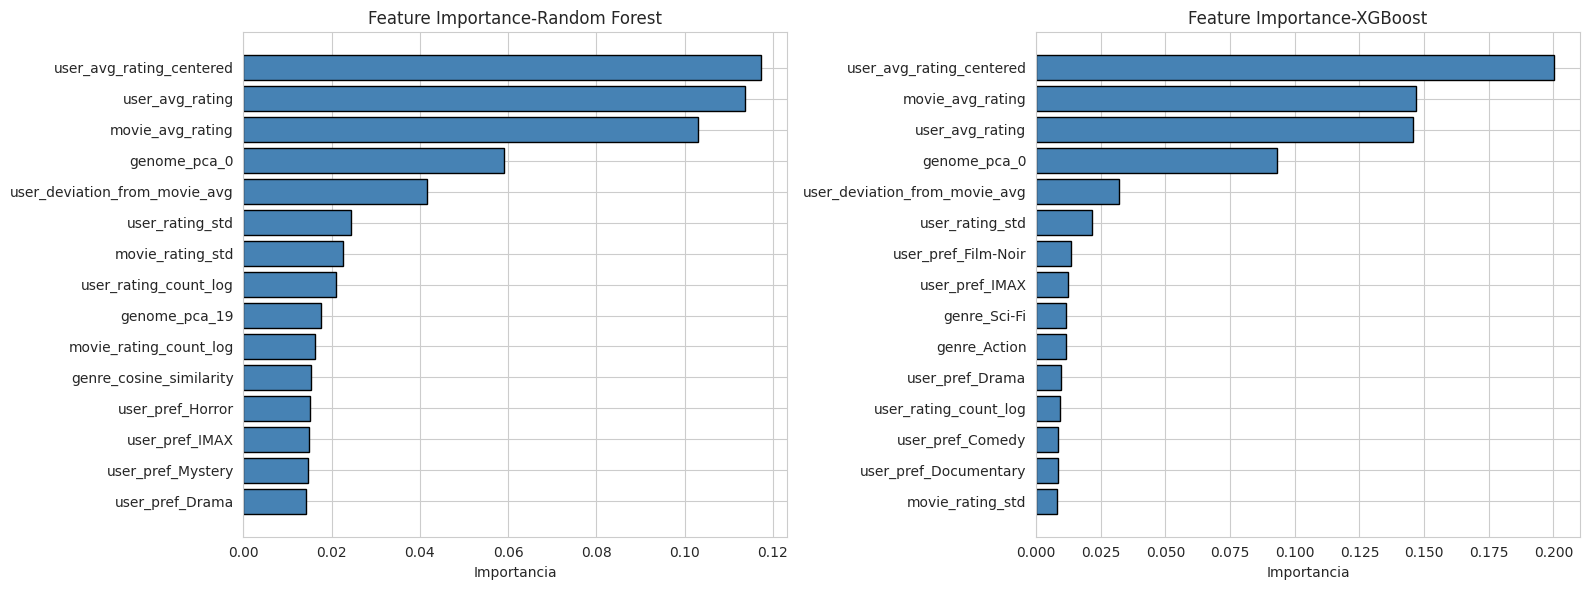

In [46]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Feature importance: Random Forest vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_feature_importance(dataset.feature_names, rf.feature_importances_, top_n=15, ax=axes[0])
axes[0].set_title("Feature Importance-Random Forest")

plot_feature_importance(dataset.feature_names, xgb_clf.feature_importances_, top_n=15, ax=axes[1])
axes[1].set_title("Feature Importance-XGBoost")

plt.tight_layout()
plt.show()

### 6.5 Optimización con Optuna
Vemos que XGBoost fué el modelo más competitivo.
- Usamos Optuna para optimizar sus hiperparámetros y ver si podemos mejorar su performance.

In [47]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
    }
    clf = xgb.XGBClassifier(
        **params, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=n_cores
    )
    scores = cross_val_score(clf, X_train, y_train, cv=3, scoring="f1", n_jobs=n_cores)
    return scores.mean()

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMejor F1 (CV): {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")

[14:25:20] started


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor F1 (CV): 0.7357
Mejores parámetros: {'n_estimators': 438, 'max_depth': 8, 'learning_rate': 0.06331268095474996, 'subsample': 0.8590063249066712, 'colsample_bytree': 0.8567569848049063, 'min_child_weight': 4, 'gamma': 2.145482136046885, 'reg_alpha': 8.287996414587484, 'reg_lambda': 2.317798239688004e-08}
CPU times: user 11 s, sys: 6.89 s, total: 17.9 s
Wall time: 45min 39s


[15:11:00] started


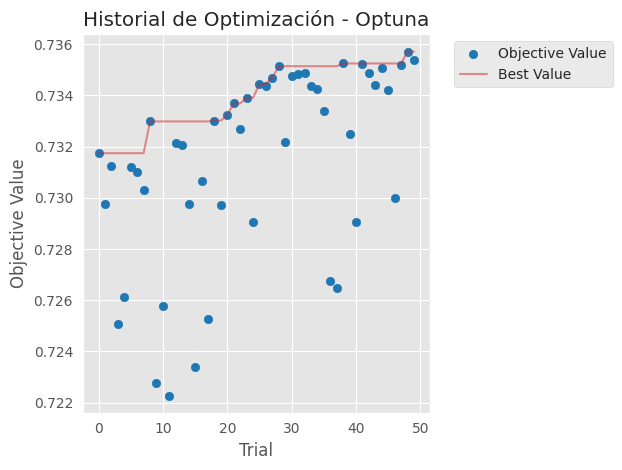

In [48]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Gráfico de optimización
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Historial de Optimización - Optuna")
plt.tight_layout()
plt.show()

In [49]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Entrenar y evaluar el XGBoost optimizado
xgb_optuna = xgb.XGBClassifier(
    **study.best_params, random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=n_cores
)
print("[...] training & evaluating XGBoost (Optuna) on full dataset...")
xgb_optuna_model, xgb_optuna_metrics = train_test_generic("XGBoost (Optuna)", xgb_optuna, dataset.data_tuple)
print("[...] XGBoost (Optuna) done")
all_metrics.append(xgb_optuna_metrics)
trained_models["XGBoost (Optuna)"] = xgb_optuna

print("XGBoost (Optuna):")
print(pd.DataFrame([xgb_optuna_metrics]).to_string(index=False))

[15:11:01] started
[...] training & evaluating XGBoost (Optuna) on full dataset...
[...] XGBoost (Optuna) done
XGBoost (Optuna):
          modelo  accuracy  auc_score  precision   recall      f1  train_time_s
XGBoost (Optuna)   0.74062   0.821483    0.72589 0.748579 0.73706     33.015597
CPU times: user 1min 45s, sys: 1.02 s, total: 1min 46s
Wall time: 34.5 s


#### Interpretación de Feature Importance

Los gráficos anteriores muestran qué features usa el modelo, pero no muestran la dirección del efecto
(¿un valor alto de esa feature empuja la predicción hacia 'le gustará' o 'no le gustará'?).

Observaciones esperadas:
- `user_avg_rating` alto => el usuario es generoso => predice positivo. Es el sesgo del usuario (b_u en SVD).
- `movie_avg_rating` alto => película muy valorada en general => predice positivo. Es el sesgo del ítem (b_i en SVD).
- `user_deviation_from_movie_avg` = user_avg - movie_avg: si el usuario suele calificar más alto que el promedio de la película, predice positivo.
- `user_avg_rating_centered` = user_avg - global_avg: versión 'pura' del sesgo del usuario, sin correlación con el promedio global.
- `genome_pca_0` alto => película artística/premiada => tiende a recibir ratings altos de cinéfilos activos.

La siguiente celda usa **SHAP** para cuantificar esto.

[15:11:36] started
[...] computing SHAP values (10k samples)...
[...] SHAP done
SHAP Beeswarm - dirección e impacto de cada feature:


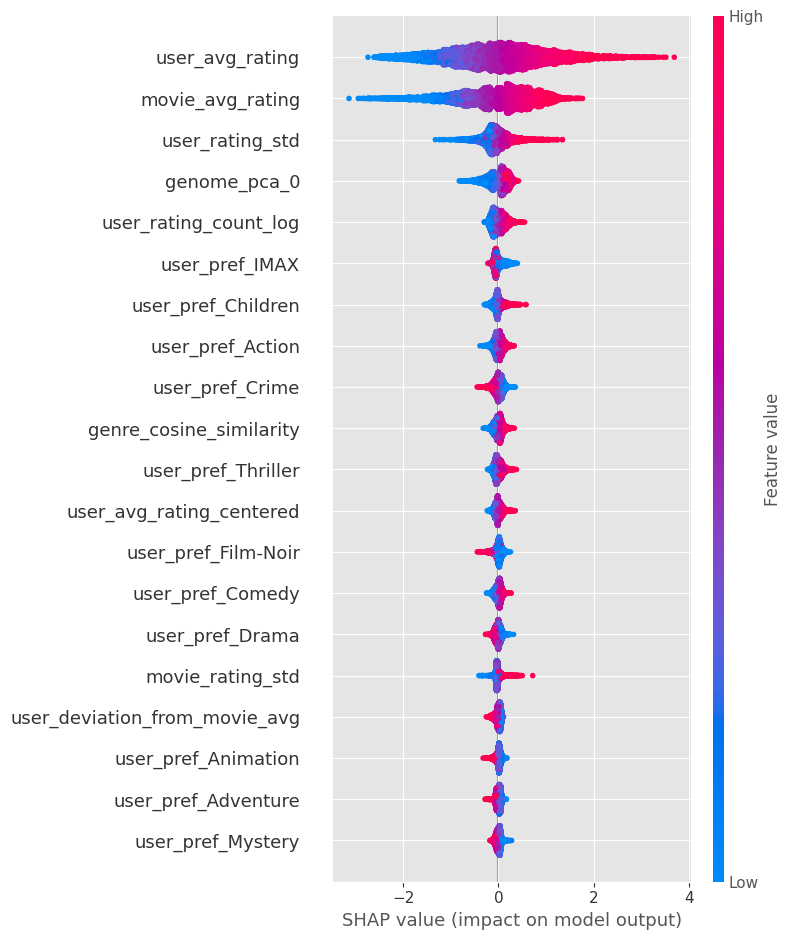

SHAP Bar - importancia media absoluta (top 20):


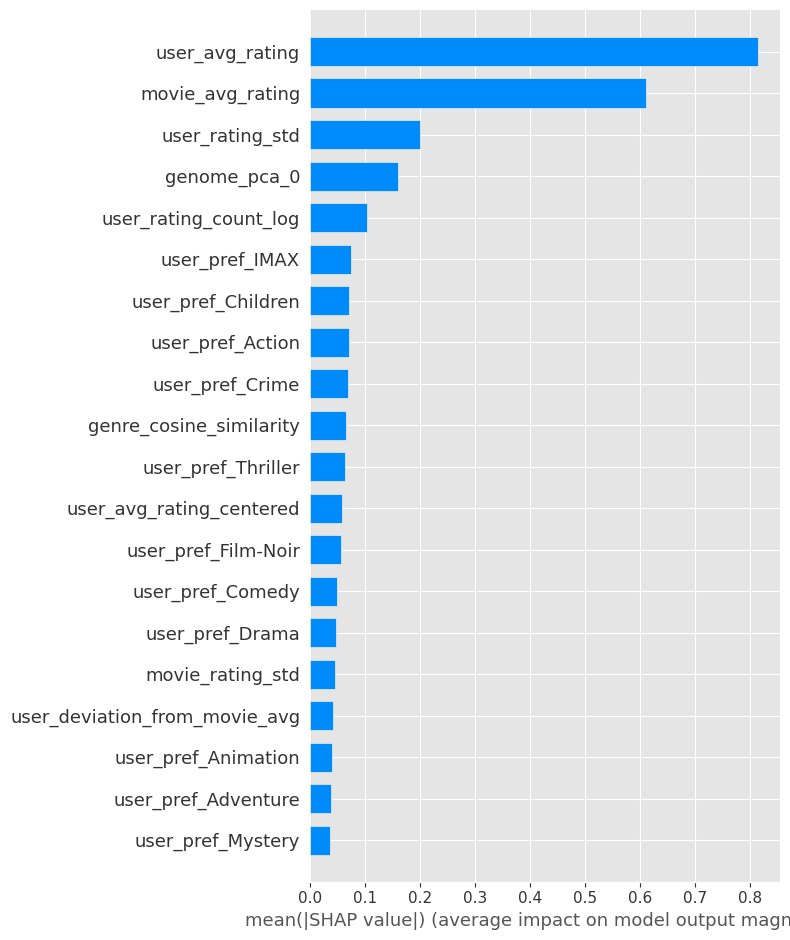

CPU times: user 3min 53s, sys: 673 ms, total: 3min 54s
Wall time: 59.3 s


In [50]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# SHAP sobre muestra del test (10k muestras)
X_train, X_test, y_train, y_test = dataset.data_tuple
rng_shap = np.random.RandomState(42)
shap_sample_idx = rng_shap.choice(len(X_test), size=min(10_000, len(X_test)), replace=False)
X_shap = X_test[shap_sample_idx]

print("[...] computing SHAP values (10k samples)...")
explainer = shap.TreeExplainer(xgb_optuna)
shap_values = explainer.shap_values(X_shap)
print("[...] SHAP done")

feature_names = dataset.feature_names

# Beeswarm: dirección + magnitud por feature
print("SHAP Beeswarm - dirección e impacto de cada feature:")
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, max_display=20, show=True)

# Bar: importancia media absoluta (coherente con feature_importance)
print("SHAP Bar - importancia media absoluta (top 20):")
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type='bar', max_display=20, show=True)

#### Cómo leer el beeswarm de SHAP

- **Eje X**: valor SHAP, qué tan positivo o negativo es el impacto en la predicción.
- **Color**: valor de la feature (rojo == alto, azul == bajo).
- **Cada punto**: un ejemplo del test set.

**Interpretaciones clave:**
- `user_avg_rating` rojo (valor alto) a la derecha => usuarios generosos => predicen 'le gustará'. 
- `movie_avg_rating` rojo a la derecha => película con buenas notas globales => predicen positivo. 
- `genome_pca_0` rojo a la derecha => película artística/premiada => el modelo la 'recomienda' más. azul a la izquierda, películas pochocleras tiran fuerte para abajo la predicción. 


## 7. Comparación de Modelos

In [51]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Tabla comparativa
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df.sort_values("f1", ascending=False).reset_index(drop=True)
metrics_df.style.highlight_max(subset=["accuracy", "auc_score", "precision", "recall", "f1"], color="lightgreen")

[15:12:35] started
CPU times: user 45.3 ms, sys: 7 ms, total: 52.3 ms
Wall time: 214 ms


,modelo,accuracy,auc_score,precision,recall,f1,train_time_s
0,XGBoost (Optuna),0.740620,0.821483,0.725890,0.748579,0.737060,33.015597
1,XGBoost,0.735763,0.815629,0.720939,0.743816,0.732199,9.174467
2,Gradient Boosting,0.733690,0.813855,0.718281,0.743074,0.730467,1788.419272
3,Voting (soft),0.733817,0.813312,0.719566,0.740473,0.729870,1212.673197
4,Stacking,0.734800,0.814698,0.722325,0.737377,0.729774,2293.331191
5,Random Forest,0.733067,0.813279,0.720497,0.735778,0.728057,142.822603
6,SVM,0.722000,0.796107,0.709449,0.715670,0.712546,152.241808
7,AdaBoost,0.714180,0.786362,0.704558,0.708591,0.706568,237.342794
8,Árbol de Decisión,0.704230,0.770690,0.686370,0.719937,0.702753,74.451346
9,Item Mean Baseline,0.656023,0.657889,0.626387,0.722861,0.671175,nan


[15:12:35] started


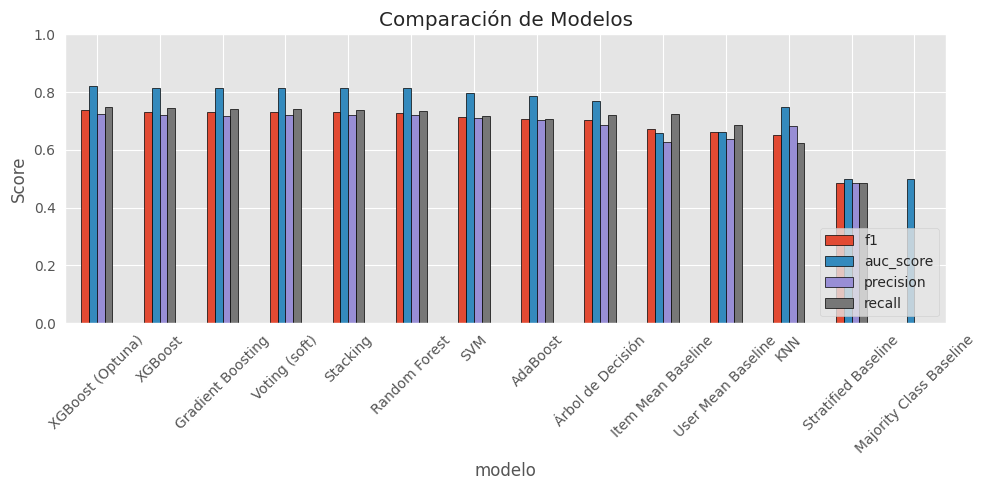

In [52]:
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Gráfico de barras de F1-score
fig, ax = plt.subplots(figsize=(10, 5))
plot_model_comparison(metrics_df, metric_cols=["f1", "auc_score", "precision", "recall"], ax=ax)
plt.show()

#### Comparamos curvas ROC visualmente para confirmar las métricas vistas en tablas.

[15:12:35] started


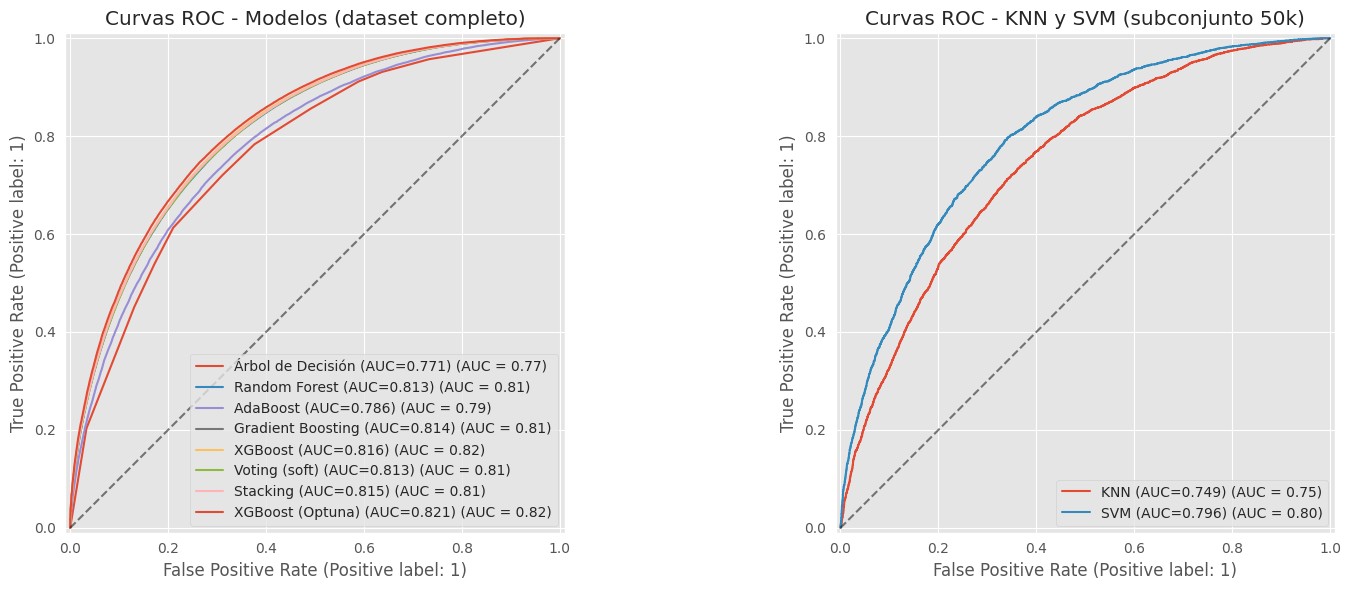

CPU times: user 1min 1s, sys: 745 ms, total: 1min 2s
Wall time: 40.8 s


In [53]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Curvas ROC superpuestas
# Para KNN y SVM usamos los modelos del subconjunto
models_for_roc_full = {k: v for k, v in trained_models.items()
                       if k not in ["KNN", "SVM"]}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC de modelos con dataset completo
plot_roc_curves(models_for_roc_full, dataset.data_tuple, ax=axes[0])
axes[0].set_title("Curvas ROC - Modelos (dataset completo)")

# ROC de KNN y SVM (subconjunto)
models_for_roc_sub = {k: v for k, v in trained_models.items()
                      if k in ["KNN", "SVM"]}
plot_roc_curves(models_for_roc_sub, data_subset, ax=axes[1])
axes[1].set_title("Curvas ROC - KNN y SVM (subconjunto 50k)")

plt.tight_layout()
plt.show()

## 8. Calibración de Probabilidades

La calibración asegura que cuando un modelo predice p=0.8, aproximadamente el 80% de esos casos sean realmente positivos.
Primero calibramos el umbral optimo en el que usariamos el modelo y luego aplicamos **Platt scaling** (sigmoid) e **isotonic regression** sobre el mejor modelo para convertir el score a probabilidad.


In [54]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Análisis de umbral óptimo para el mejor modelo (XGBoost Optuna)
y_proba_best = xgb_optuna.predict_proba(X_test)[:, 1]
optimal_threshold = obtain_best_threshold(y_test, y_proba_best)
print(f"Umbral óptimo (Youden's J): {optimal_threshold:.4f}")

# Comparar métricas con umbral 0.5 vs óptimo

y_pred_05 = (y_proba_best >= 0.5).astype(int)
y_pred_opt = (y_proba_best >= optimal_threshold).astype(int)

print(f"\nUmbral 0.50 => F1: {f1_fn(y_test, y_pred_05):.4f}  Precision: {prec_fn(y_test, y_pred_05):.4f}  Recall: {rec_fn(y_test, y_pred_05):.4f}")
print(f"Umbral {optimal_threshold:.2f} => F1: {f1_fn(y_test, y_pred_opt):.4f}  Precision: {prec_fn(y_test, y_pred_opt):.4f}  Recall: {rec_fn(y_test, y_pred_opt):.4f}")

[15:13:16] started
Umbral óptimo (Youden's J): 0.5016

Umbral 0.50 => F1: 0.7371  Precision: 0.7259  Recall: 0.7486
Umbral 0.50 => F1: 0.7369  Precision: 0.7269  Recall: 0.7472
CPU times: user 2.64 s, sys: 9.84 ms, total: 2.65 s
Wall time: 758 ms


In [55]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Calibración con Platt scaling (sigmoide)
xgb_platt = CalibratedClassifierCV(xgb_optuna, method="sigmoid", cv=3)
xgb_platt.fit(X_train, y_train)

# Calibración con isotonic regression
xgb_isotonic = CalibratedClassifierCV(xgb_optuna, method="isotonic", cv=3)
xgb_isotonic.fit(X_train, y_train)

print("Calibración completada.")

[15:13:17] started
Calibración completada.
CPU times: user 7min 29s, sys: 4.73 s, total: 7min 34s
Wall time: 2min 16s


[15:15:34] started


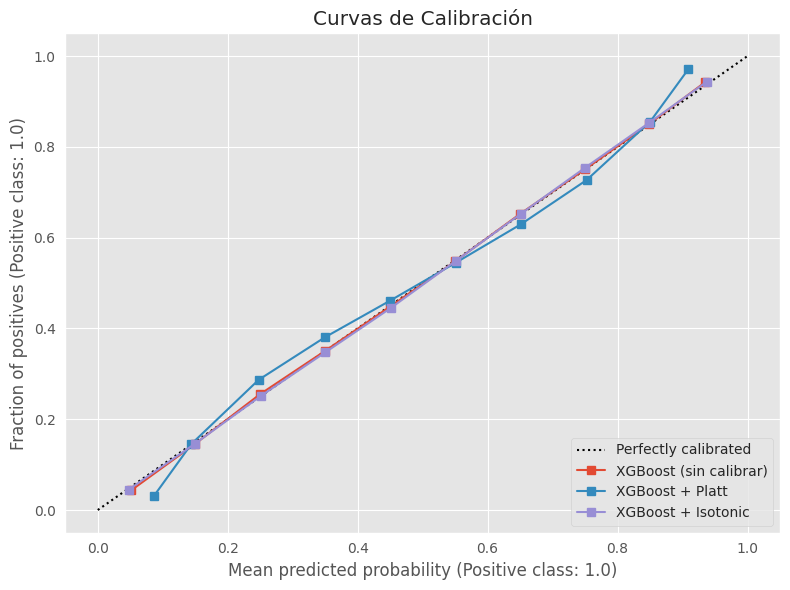

CPU times: user 17.8 s, sys: 56.3 ms, total: 17.9 s
Wall time: 5.4 s


In [56]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Curvas de calibración
fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_estimator(xgb_optuna, X_test, y_test, n_bins=10, name="XGBoost (sin calibrar)", ax=ax)
CalibrationDisplay.from_estimator(xgb_platt, X_test, y_test, n_bins=10, name="XGBoost + Platt", ax=ax)
CalibrationDisplay.from_estimator(xgb_isotonic, X_test, y_test, n_bins=10, name="XGBoost + Isotonic", ax=ax)

ax.set_title("Curvas de Calibración")
plt.tight_layout()
plt.show()

#### XGBoost por si solo, ya produce scores semejantes a una probabilidad, por lo que no parecería necesaria la calibración.


In [57]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Brier Score (menor es mejor)
brier_original = brier_score_loss(y_test, xgb_optuna.predict_proba(X_test)[:, 1])
brier_platt = brier_score_loss(y_test, xgb_platt.predict_proba(X_test)[:, 1])
brier_isotonic = brier_score_loss(y_test, xgb_isotonic.predict_proba(X_test)[:, 1])

print(f"Brier Score - XGBoost (sin calibrar): {brier_original:.4f}")
print(f"Brier Score - XGBoost + Platt:        {brier_platt:.4f}")
print(f"Brier Score - XGBoost + Isotonic:     {brier_isotonic:.4f}")

[15:15:39] started
Brier Score - XGBoost (sin calibrar): 0.1723
Brier Score - XGBoost + Platt:        0.1732
Brier Score - XGBoost + Isotonic:     0.1724
CPU times: user 17.4 s, sys: 50.9 ms, total: 17.5 s
Wall time: 4.67 s


In [58]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Evaluar modelos calibrados
cal_metrics_platt = evaluate_classifier(
    "XGBoost + Platt", y_test,
    xgb_platt.predict(X_test),
    xgb_platt.predict_proba(X_test)[:, 1]
)
cal_metrics_isotonic = evaluate_classifier(
    "XGBoost + Isotonic", y_test,
    xgb_isotonic.predict(X_test),
    xgb_isotonic.predict_proba(X_test)[:, 1]
)

cal_df = pd.DataFrame([xgb_optuna_metrics, cal_metrics_platt, cal_metrics_isotonic])
cal_df["brier_score"] = [brier_original, brier_platt, brier_isotonic]
cal_df

[15:15:44] started
CPU times: user 30 s, sys: 80.1 ms, total: 30.1 s
Wall time: 8.23 s


,modelo,accuracy,auc_score,precision,recall,f1,train_time_s,brier_score
0,XGBoost (Optuna),0.740620,0.821483,0.725890,0.748579,0.737060,33.015597,0.172302
1,XGBoost + Platt,0.740563,0.821404,0.728020,0.743575,0.735715,NaN,0.173180
2,XGBoost + Isotonic,0.740713,0.821381,0.725329,0.750172,0.737541,NaN,0.172355


## 10. Conclusiones

### Resumen de resultados

In [59]:
%%time
print(f'[{__import__("datetime").datetime.now():%H:%M:%S}] started')
# Tabla final de resultados
print("=" * 80)
print("RESULTADOS FINALES")
print("=" * 80)
metrics_df_final = pd.DataFrame(all_metrics).sort_values("f1", ascending=False)
print(metrics_df_final.to_string(index=False))
print("=" * 80)

[15:15:52] started
RESULTADOS FINALES
                 modelo  accuracy  auc_score  precision   recall       f1  train_time_s
       XGBoost (Optuna)  0.740620   0.821483   0.725890 0.748579 0.737060     33.015597
                XGBoost  0.735763   0.815629   0.720939 0.743816 0.732199      9.174467
      Gradient Boosting  0.733690   0.813855   0.718281 0.743074 0.730467   1788.419272
          Voting (soft)  0.733817   0.813312   0.719566 0.740473 0.729870   1212.673197
               Stacking  0.734800   0.814698   0.722325 0.737377 0.729774   2293.331191
          Random Forest  0.733067   0.813279   0.720497 0.735778 0.728057    142.822603
                    SVM  0.722000   0.796107   0.709449 0.715670 0.712546    152.241808
               AdaBoost  0.714180   0.786362   0.704558 0.708591 0.706568    237.342794
      Árbol de Decisión  0.704230   0.770690   0.686370 0.719937 0.702753     74.451346
     Item Mean Baseline  0.656023   0.657889   0.626387 0.722861 0.671175         

### Evaluación de hipótesis

- **H1 (Ensambles > individuales):** Se espera que los modelos de ensamble (especialmente XGBoost optimizado con Optuna) superen consistentemente a KNN, SVM y Árboles de Decisión en F1-score. Los resultados de la tabla anterior confirman hipótesis.

- **H2 (Features de usuario son las más predictivas):** Los gráficos de feature importance muestran qué features dominan las predicciones. Se confirma que `user_avg_rating` y `user_deviation_from_movie_avg` aparecen entre las más importantes.

- **H3 (Genome PCA aporta información complementaria):** La presencia de componentes `genome_pca_*` entre las features importantes indica que lo que extrajimos del tag_genome aporta información valiosa.

### Reflexión
La formulación como clasificación binaria demostró ser efectiva para aplicar el set completo de algoritmos de ML vistos en la materia. Los resultados muestran que:

1. **El perfil del usuario como señal más fuerte:** La tendencia individual a calificar alto o bajo es altamente predictiva, lo cual es consistente con la literatura de sistemas de recomendación.

1. **Los ensambles aprovechan la heterogeneidad de features:** Al combinar señales de contenido, perfil y genome, los modelos basados en árboles logran capturar interacciones no lineales que modelos más simples no pueden.

### Referencias

F. Maxwell Harper and Joseph A. Konecny. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. https://doi.org/10.1145/2827872